In [34]:
from pykoa.koa import Koa
import os
from astropy.table import Table, Column
from astropy.io import fits
from pathlib import Path
from astropy import wcs
from astropy.nddata import Cutout2D
from matplotlib import pyplot as plt

In [43]:
# Load in KOA FITS
koa_file = Path("/Users/bdigia/myg3/data/nirc2_calib0_2016-08-06_KOA/lev0/N2.20160806.41941.fits")
koa_fits = fits.open(koa_file.as_posix())
koa_img = koa_fits[0].data
koa_hdr = koa_fits[0].header

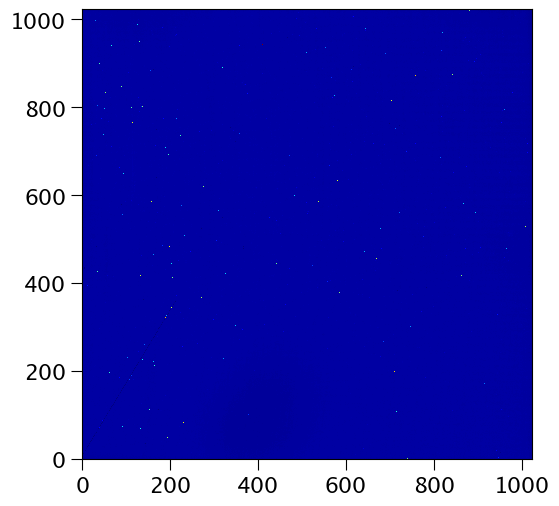

In [44]:
# Show original KOA image
plt.imshow(koa_img)
plt.show()

In [45]:
if 'XSTREHL' in koa_hdr:
    eng_coords = np.array([float(koa_hdr['XSTREHL']), float(koa_hdr['YSTREHL'])])
    # 0-index the coordinates
    eng_coords -= 1 

# Find engineering star coordinates (finding brightest pixel in image)
peak_pixel_pos = np.argwhere(koa_img == koa_img.max())
# Cutout around engineering star 
coords = peak_pixel_pos[0]
cutout_obj = Cutout2D(koa_img, peak_pixel_pos[0], [256, 256], mode='trim')

In [46]:
cutout_obj.data

array([[450., 452., 449., ..., 354., 360., 365.],
       [447., 472., 449., ..., 373., 360., 361.],
       [445., 451., 451., ..., 370., 344., 349.],
       ...,
       [460., 469., 468., ..., 367., 366., 352.],
       [454., 455., 448., ..., 356., 351., 329.],
       [442., 462., 442., ..., 353., 369., 330.]])

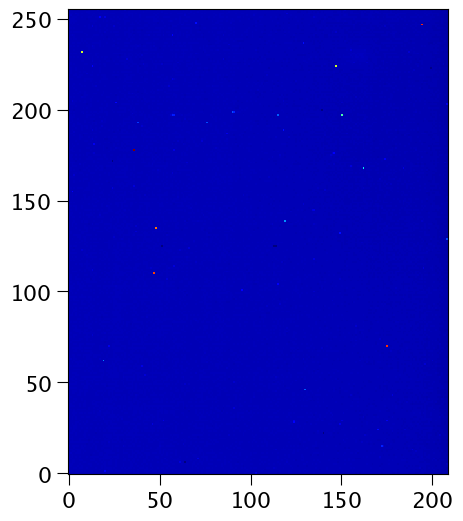

In [47]:
plt.imshow(cutout_obj.data)
plt.show()

In [ ]:
# 'Crop' KOA FITS by making new FITS
w = wcs.WCS(koa_fits[0].header)
new_fits = fits.PrimaryHDU()
new_fits.data = koa_fits[0].data[,]
new_fits.header = koa_fits[0].header
new_fits.header.update(w[,].to_header())

In [ ]:

f = fits.open('file.fits')
w = wcs.WCS(f[0].header)
newf = fits.PrimaryHDU()
newf.data = f[0].data[100:-100,100:-100]
newf.header = f[0].header
newf.header.update(w[100:-100,100:-100].to_header())